# WellSound — Acoustic Ambiance Classifier
**APAN 5570 — WellSound Group Project**

Trains a 3-layer MLP to classify room acoustic quality as:
**Focus | Collaborative | Lively | Disruptive**

### Feature pipeline per 0.5-second window
1. `compute_bandpower()` — 5-band FFT energy *(intermediate, not seen by model)*
2. `extract_features()` — derives 6 features: `rms_db` + 5 spectral ratios
3. `StandardScaler` → MLP (6 → 16 → 8 → 4)
4. Export `weights_2.json` for on-device inference

> ⚠️ **Output:** `weights_2.json` — upload to `/flash/` on Core2 before running `wellsound_odi.py`

## Cell 1 — Imports & plot style

In [1]:
import numpy as np
import json, math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import wavfile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams.update({
    'figure.dpi':        100,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

COLORS = {
    'Focus':         'steelblue',
    'Collaborative': 'mediumseagreen',
    'Lively':        'orange',
    'Disruptive':    'orangered',
}

print('Imports OK.')

Imports OK.


## Cell 2 — Constants
> ⚠️ These must match `wellsound_odi.py` exactly.
> If you change any value here, update the inference script too.

In [2]:
# ── WAV files — one per class, recorded at 16 kHz mono ───────────────────────
WAV_FILES = {
    'Focus':         'focus.wav',
    'Collaborative': 'collab.wav',
    'Lively':        'lively.wav',
    'Disruptive':    'disruptive.wav',
}

CLASSES = ['Focus', 'Collaborative', 'Lively', 'Disruptive']

# ── Signal-processing constants ── MUST match inference script exactly ────────
SAMPLE_RATE = 16000        # Hz  — Core2 max, needed for 5k–8k band
WIN_SAMPLES = 4000    # samples per window = 0.25 s at 16 kHz
KEEP_SEC    = None         # None → use full recording; set e.g. to 10 to trim

# ── Frequency bands ── MUST match inference script exactly ───────────────────
BANDS = [
    (0,    200),   # BP Sub-bass — HVAC rumble, deep bass thump
    (200,  500),   # BP Low      — low-mid, background presence
    (500,  2000),  # BP Mid      — core voice/speech range
    (2000, 5000),  # BP High     — harshness, speech intelligibility
    (5000, 8000),  # BP Air      — high-freq noise (chairs, printers)
]
BAND_NAMES = ['Sub-bass', 'Low', 'Mid', 'High', 'Air']

# ── FFT sub-window parameters ── MUST match inference script exactly ──────────
SUB_N   = 256                        # FFT size per sub-window, updated from 1024 to 256 to increase speed of inference
N_SUB   = WIN_SAMPLES // SUB_N      # sub-windows per 0.5-s window  → 31
SUB_HZ  = SAMPLE_RATE / SUB_N      # Hz per FFT bin                → 62.5

print(f'SAMPLE_RATE : {SAMPLE_RATE} Hz')
print(f'WIN_SAMPLES : {WIN_SAMPLES} samples = {WIN_SAMPLES/SAMPLE_RATE:.2f} s')
print(f'SUB_N       : {SUB_N}   N_SUB : {N_SUB}   SUB_HZ : {SUB_HZ} Hz/bin')
print()
print('Band bin boundaries:')
for (f_lo, f_hi), name in zip(BANDS, BAND_NAMES):
    lo = int(f_lo / SUB_HZ)
    hi = min(int(f_hi / SUB_HZ), SUB_N // 2 + 1)
    print(f'  {name:10s} ({f_lo:5d}–{f_hi:5d} Hz)  → bins [{lo:3d}, {hi:3d})')

SAMPLE_RATE : 16000 Hz
WIN_SAMPLES : 4000 samples = 0.25 s
SUB_N       : 256   N_SUB : 15   SUB_HZ : 62.5 Hz/bin

Band bin boundaries:
  Sub-bass   (    0–  200 Hz)  → bins [  0,   3)
  Low        (  200–  500 Hz)  → bins [  3,   8)
  Mid        (  500– 2000 Hz)  → bins [  8,  32)
  High       ( 2000– 5000 Hz)  → bins [ 32,  80)
  Air        ( 5000– 8000 Hz)  → bins [ 80, 128)


## Cell 3 — Load WAV files

In [3]:
def load_wav(path, keep_sec=None):
    """Load WAV → (int16 array, float array normalised to [-1, 1])."""
    sr, raw = wavfile.read(path)
    if sr != SAMPLE_RATE:
        raise ValueError(f'{path}: expected {SAMPLE_RATE} Hz, got {sr} Hz')
    if raw.ndim > 1:
        raw = raw[:, 0]              # stereo → mono
    if keep_sec is not None:
        raw = raw[:int(keep_sec * sr)]
    int16  = raw.astype(np.int16)
    floats = int16.astype(np.float64) / 32768.0
    return int16, floats

recordings_i16, recordings_f32 = {}, {}
for label, path in WAV_FILES.items():
    i16, f32 = load_wav(path, keep_sec=KEEP_SEC)
    recordings_i16[label] = i16
    recordings_f32[label] = f32
    dur = len(i16) / SAMPLE_RATE
    print(f'{label:15s}  {len(i16):7d} samples  {dur:.1f} s  '
          f'int16 [{i16.min():7d}, {i16.max():6d}]  '
          f'float [{f32.min():.3f}, {f32.max():.3f}]')

Focus            4800000 samples  300.0 s  int16 [  -2052,   1863]  float [-0.063, 0.057]
Collaborative    4800000 samples  300.0 s  int16 [ -15429,  11096]  float [-0.471, 0.339]
Lively           4800007 samples  300.0 s  int16 [ -32768,  32767]  float [-1.000, 1.000]
Disruptive       4800000 samples  300.0 s  int16 [ -32768,  32767]  float [-1.000, 1.000]


## Cell 4 — Feature extraction

Pipeline (mirrors inference script exactly):

```
int16 window
  → compute_bandpower()   [5 raw band energies — intermediate only]
  → rms_db()              [feature 0: loudness]
  → spectral ratios       [features 1–5: frequency mix]
  → 6-element feature vector → model
```

| Index | Name | Description |
|-------|------|-------------|
| 0 | `rms_db` | Overall loudness in dB |
| 1 | `speech_ratio` | Energy fraction 500–2k Hz (core voice) |
| 2 | `low_ratio` | Energy fraction 0–500 Hz (rumble/bass) |
| 3 | `high_ratio` | Energy fraction 2k–8k Hz (harshness) |
| 4 | `mid_ratio` | Energy fraction 200–500 Hz (low-mid) |
| 5 | `centroid` | Spectral centre of mass (Hz) |

In [4]:
def compute_bandpower(window_int16):
    """
    5-band bandpower using N_SUB x SUB_N-point sub-window FFTs.
    Matches the pure-Python FFT in the inference script exactly.
    Returns list of 5 floats (raw energy — not seen by model directly).
    """
    bp = np.zeros(len(BANDS))
    for w in range(N_SUB):
        sub    = window_int16[w * SUB_N : (w + 1) * SUB_N].astype(np.float64)
        Xf     = np.fft.rfft(sub)
        mag_sq = Xf.real**2 + Xf.imag**2
        n_bins = len(mag_sq)
        for i, (f_lo, f_hi) in enumerate(BANDS):
            lo = int(f_lo / SUB_HZ)
            hi = min(int(f_hi / SUB_HZ), n_bins)
            bp[i] += float(np.sum(mag_sq[lo:hi])) / SUB_N
    return list(bp / N_SUB)


def rms_db(window_int16):
    """
    RMS energy in dB relative to full int16 scale.
    Matches rms_db() in inference script exactly.
    """
    floats = window_int16.astype(np.float64) / 32768.0
    rms    = np.sqrt(np.mean(floats**2) + 1e-10)
    return float(20.0 * np.log10(rms))


def extract_features(window_int16):
    """
    6-element feature vector — identical logic to extract_features()
    in WellSound_Inference_UIFlow.py.
    """
    bp                            = compute_bandpower(window_int16)
    sub_bass, low, mid, high, air = bp
    eps                           = 1e-10
    full                          = sub_bass + low + mid + high + air + eps

    speech_ratio = mid              / full   # 500–2000 Hz — core voice
    low_ratio    = (sub_bass + low) / full   # 0–500 Hz   — rumble/bass
    high_ratio   = (high + air)     / full   # 2k–8k Hz   — harshness
    mid_ratio    = low              / full   # 200–500 Hz — low-mid presence
    centroid     = (sub_bass * 100.0 + low * 350.0 + mid * 1250.0 +
                    high * 3500.0 + air * 6500.0) / full

    return [rms_db(window_int16), speech_ratio, low_ratio,
            high_ratio, mid_ratio, centroid]

FEATURE_NAMES = ['rms_db', 'speech_ratio', 'low_ratio',
                 'high_ratio', 'mid_ratio', 'centroid']

print('Feature functions defined.')
print(f'Feature vector length : {len(FEATURE_NAMES)}')
print(f'Features              : {FEATURE_NAMES}')

Feature functions defined.
Feature vector length : 6
Features              : ['rms_db', 'speech_ratio', 'low_ratio', 'high_ratio', 'mid_ratio', 'centroid']


## Cell 5 — Build feature matrix

In [5]:
def extract_all_features(recordings_i16):
    """Non-overlapping 0.5-second windows over every recording."""
    X_rows, y_rows = [], []
    for label, audio in recordings_i16.items():
        n_windows = len(audio) // WIN_SAMPLES
        for k in range(n_windows):
            win = audio[k * WIN_SAMPLES : (k + 1) * WIN_SAMPLES]
            X_rows.append(extract_features(win))
            y_rows.append(label)
        print(f'{label:15s}  {n_windows} windows')
    return np.array(X_rows, dtype=np.float64), np.array(y_rows)

X, y = extract_all_features(recordings_i16)

print()
print(f'Feature matrix : {X.shape}   ({X.shape[0]} windows × {X.shape[1]} features)')
print(f'Class balance  : {dict(zip(*np.unique(y, return_counts=True)))}')

# Warn if any class is under the recommended minimum
for cls, count in zip(*np.unique(y, return_counts=True)):
    if count < 200:
        print(f'⚠️  {cls} only has {count} windows (recommend ≥200) — consider recording more')

Focus            1200 windows
Collaborative    1200 windows
Lively           1200 windows
Disruptive       1200 windows

Feature matrix : (4800, 6)   (4800 windows × 6 features)
Class balance  : {'Collaborative': 1200, 'Disruptive': 1200, 'Focus': 1200, 'Lively': 1200}


## Cell 6 — Feature distributions (sanity check)
Verify the 4 classes are separable before training.
`rms_db` and `speech_ratio` are the two most important axes — if they overlap heavily, consider recording more varied examples.

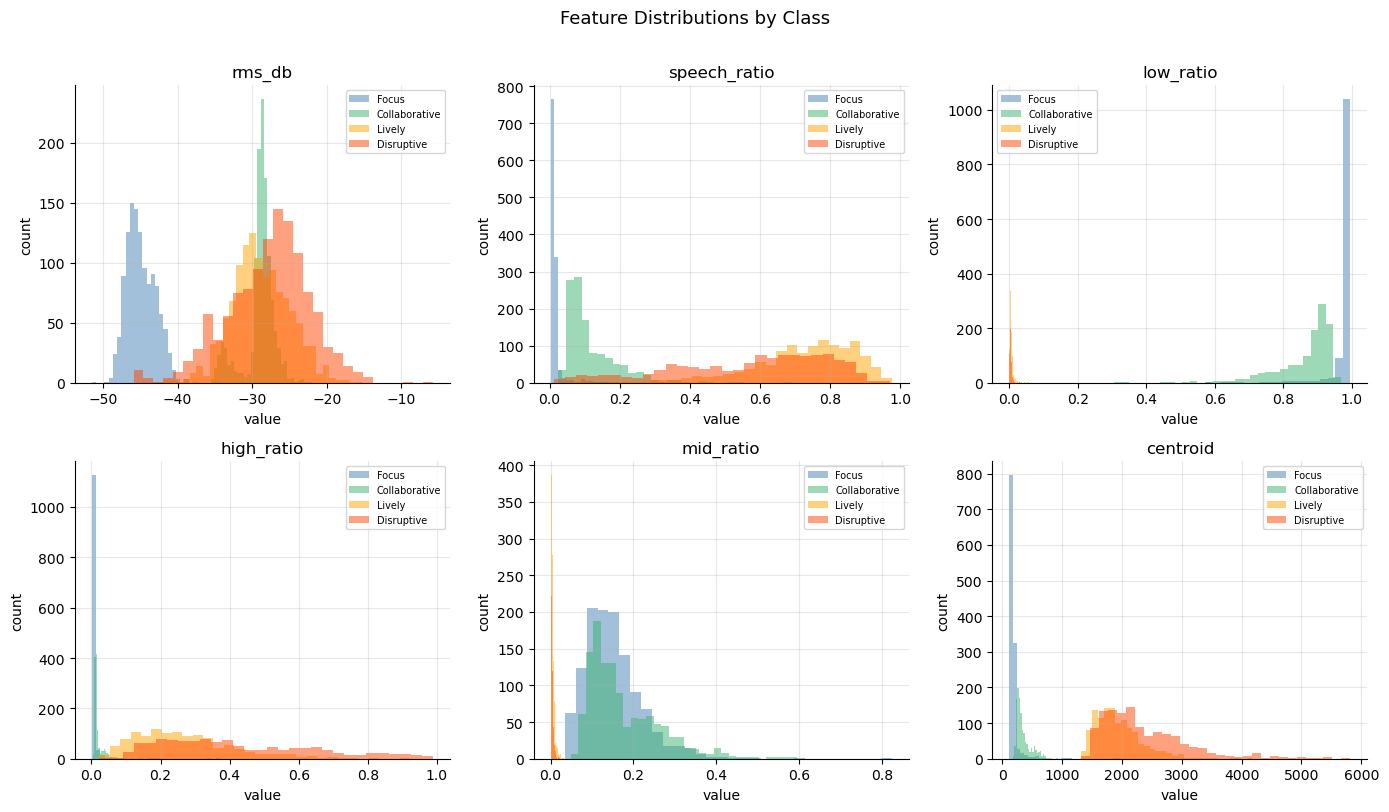

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, feat_name, feat_idx in zip(axes, FEATURE_NAMES, range(len(FEATURE_NAMES))):
    for label in CLASSES:
        mask = y == label
        ax.hist(X[mask, feat_idx], bins=30, alpha=0.5,
                color=COLORS[label], label=label)
    ax.set_title(feat_name)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Cell 7 — Train / test split & scaling
`StandardScaler` parameters (`mean`, `std`) are exported to `weights_2.json` so the Core2 can apply identical normalisation at inference time.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# StandardScaler — parameters exported to weights_2.json for on-device use
scaler = StandardScaler()
Xtr    = scaler.fit_transform(X_train)
Xte    = scaler.transform(X_test)

print(f'Train : {Xtr.shape[0]} windows')
print(f'Test  : {Xte.shape[0]} windows')
print()
print('Scaler mean :', [round(v, 4) for v in scaler.mean_])
print('Scaler std  :', [round(v, 4) for v in scaler.scale_])

Train : 3600 windows
Test  : 1200 windows

Scaler mean : [-32.6237, 0.3578, 0.4626, 0.1796, 0.0843, 1211.1199]
Scaler std  : [8.0174, 0.3285, 0.4614, 0.2215, 0.0989, 1050.7934]


## Cell 8 — Train MLP
Architecture: **6 → 16 → 8 → 4** (inputs → hidden → hidden → classes)

In [8]:
clf = MLPClassifier(
    hidden_layer_sizes = (16, 8),
    activation         = 'relu',
    solver             = 'adam',
    alpha              = 1e-3,      # L2 regularisation
    max_iter           = 1000,
    random_state       = 42,
)
clf.fit(Xtr, y_train)

y_pred    = clf.predict(Xte)
train_acc = clf.score(Xtr, y_train)
test_acc  = clf.score(Xte,  y_test)

print(f'Training iterations : {clf.n_iter_}')
print(f'Final loss          : {clf.loss_:.4f}')
print(f'Training accuracy   : {train_acc:.1%}')
print(f'Test accuracy       : {test_acc:.1%}')
print()
print(classification_report(y_test, y_pred, zero_division=0))

Training iterations : 161
Final loss          : 0.2723
Training accuracy   : 86.6%
Test accuracy       : 86.1%

               precision    recall  f1-score   support

Collaborative       1.00      1.00      1.00       300
   Disruptive       0.73      0.70      0.72       300
        Focus       1.00      1.00      1.00       300
       Lively       0.71      0.74      0.73       300

     accuracy                           0.86      1200
    macro avg       0.86      0.86      0.86      1200
 weighted avg       0.86      0.86      0.86      1200



## Cell 9 — Confusion matrix

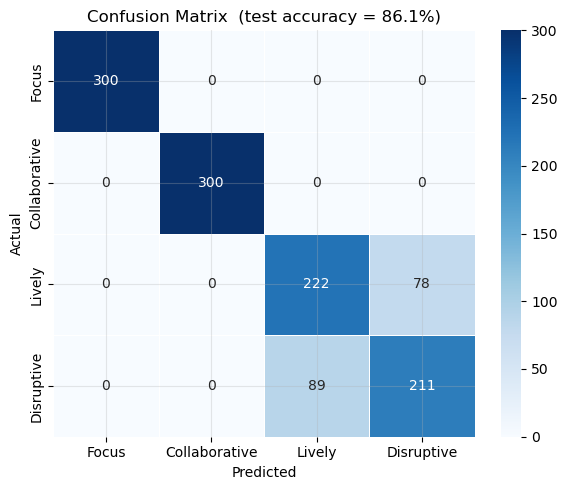

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix  (test accuracy = {test_acc:.1%})')
plt.tight_layout()
plt.show()

## Cell 10 — Export `weights_2.json`
Exports everything the inference script needs: model weights, scaler parameters, and class list.

> **Next step:** upload `weights_2.json` to `/flash/` on the Core2.

In [12]:
def to_python_list(arr):
    """Recursively convert numpy arrays to plain Python lists for JSON."""
    if isinstance(arr, np.ndarray):
        return arr.tolist()
    return arr

weights = {
    # MLP weight matrices and bias vectors
    'coefs':      [to_python_list(w) for w in clf.coefs_],
    'intercepts': [to_python_list(b) for b in clf.intercepts_],
    # StandardScaler parameters — 6 values each (one per feature)
    'scaler_mean': to_python_list(scaler.mean_),
    'scaler_std':  to_python_list(scaler.scale_),
    # Class order — must match CLASSES list exactly
    'classes':     list(clf.classes_),
}

output_path = 'weights_2.json'
with open(output_path, 'w') as f:
    json.dump(weights, f)

print(f'Saved: {output_path}')
print()
print('Contents summary:')
print(f'  classes      : {weights["classes"]}')
print(f'  scaler_mean  : {[round(v,4) for v in weights["scaler_mean"]]}')
print(f'  scaler_std   : {[round(v,4) for v in weights["scaler_std"]]}')
for i, (w, b) in enumerate(zip(weights['coefs'], weights['intercepts'])):
    print(f'  layer {i+1}      : W {np.array(w).shape}  b {np.array(b).shape}')

print()
print('Next step: upload weights_2.json to /flash/ on the Core2.')

Saved: weights_2.json

Contents summary:
  classes      : ['Collaborative', 'Disruptive', 'Focus', 'Lively']
  scaler_mean  : [-32.6237, 0.3578, 0.4626, 0.1796, 0.0843, 1211.1199]
  scaler_std   : [8.0174, 0.3285, 0.4614, 0.2215, 0.0989, 1050.7934]
  layer 1      : W (6, 16)  b (16,)
  layer 2      : W (16, 8)  b (8,)
  layer 3      : W (8, 4)  b (4,)

Next step: upload weights_2.json to /flash/ on the Core2.


## Cell 11 — Alignment verification
Runs a single window through both the **training** feature function (numpy) and a reimplementation of the **inference** feature function (pure Python, no numpy — same as MicroPython).

If all rows print ✅, the two pipelines are numerically identical and you are safe to deploy.

In [11]:
def inference_extract_features(samples_list):
    """
    Pure-Python reimplementation of extract_features() from the inference
    script, using only built-in math — no numpy. Used here only to verify
    that the numpy training version and the MicroPython inference version
    produce the same numbers.
    """
    import math as _math

    SUB_N_  = 256
    N_SUB_  = WIN_SAMPLES // SUB_N_
    HZ_BIN_ = SAMPLE_RATE / SUB_N_
    BINS_   = [(int(f_lo / HZ_BIN_), min(int(f_hi / HZ_BIN_), SUB_N_ // 2 + 1))
               for (f_lo, f_hi) in BANDS]

    # Bit-reversal table
    n_bits = int(_math.log2(SUB_N_))
    br = [0] * SUB_N_
    for i in range(SUB_N_):
        r, x = 0, i
        for _ in range(n_bits):
            r = (r << 1) | (x & 1)
            x >>= 1
        br[i] = r

    wr = [_math.cos(-2.0 * _math.pi * k / SUB_N_) for k in range(SUB_N_)]
    wi = [_math.sin(-2.0 * _math.pi * k / SUB_N_) for k in range(SUB_N_)]
    re = [0.0] * SUB_N_
    im = [0.0] * SUB_N_

    def fft_sub(start):
        for i in range(SUB_N_):
            re[br[i]] = float(samples_list[start + i])
            im[br[i]] = 0.0
        stage = 2
        while stage <= SUB_N_:
            half = stage >> 1
            t_step = SUB_N_ // stage
            for s in range(0, SUB_N_, stage):
                for k in range(half):
                    t = k * t_step
                    i0 = s + k; i1 = i0 + half
                    tr = wr[t]*re[i1] - wi[t]*im[i1]
                    ti = wr[t]*im[i1] + wi[t]*re[i1]
                    re[i1] = re[i0] - tr
                    im[i1] = im[i0] - ti
                    re[i0] += tr
                    im[i0] += ti
            stage <<= 1

    bp = [0.0] * 5
    for w in range(N_SUB_):
        fft_sub(w * SUB_N_)
        for i, (lo, hi) in enumerate(BINS_):
            s = 0.0
            for k in range(lo, hi):
                s += re[k]*re[k] + im[k]*im[k]
            bp[i] += s
    norm = 1.0 / (N_SUB_ * SUB_N_)
    bp = [v * norm for v in bp]

    acc = sum((v / 32768.0)**2 for v in samples_list)
    rms = _math.sqrt(acc / len(samples_list) + 1e-10)
    db  = 20.0 * _math.log10(rms)

    sub_bass, low, mid, high, air = bp
    eps  = 1e-10
    full = sub_bass + low + mid + high + air + eps

    return [
        db,
        mid              / full,
        (sub_bass + low) / full,
        (high + air)     / full,
        low              / full,
        (sub_bass*100 + low*350 + mid*1250 + high*3500 + air*6500) / full,
    ]

# Run check on one window from each class
print('Alignment check — training numpy vs inference pure-Python:\n')
all_ok = True
for label, audio in recordings_i16.items():
    win      = audio[:WIN_SAMPLES]
    feat_np  = extract_features(win)
    feat_py  = inference_extract_features(list(win))
    max_diff = max(abs(a - b) for a, b in zip(feat_np, feat_py))
    status   = '✅' if max_diff < 1e-4 else '❌'
    if max_diff >= 1e-4:
        all_ok = False
    print(f'  {label:15s}  max diff = {max_diff:.2e}  {status}')

print()
if all_ok:
    print('✅  All features match — training and inference are consistent.')
else:
    print('❌  Mismatch detected — check BANDS, SAMPLE_RATE, WIN_SAMPLES, SUB_N.')

Alignment check — training numpy vs inference pure-Python:

  Focus            max diff = 2.78e-17  ✅
  Collaborative    max diff = 2.84e-14  ✅
  Lively           max diff = 2.27e-13  ✅
  Disruptive       max diff = 2.27e-13  ✅

✅  All features match — training and inference are consistent.
